In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt

In [ ]:
columns = [
    "packets_per_sec",
    "bytes_per_sec",
    "syn_count",
    "ack_count",
    "udp_count",
    "icmp_count",
    "unique_src_ips",
    "avg_packet_size",
    "label"
]

df = pd.read_csv("traffic_dataset_multi.csv", names=columns)

df["label"].value_counts()
df

,packets_per_sec,bytes_per_sec,syn_count,ack_count,udp_count,icmp_count,unique_src_ips,avg_packet_size,label
0,1.4,118.4,0,0,0,5,2,84.571429,0
1,2.4,216.4,0,0,0,10,2,90.166667,0
2,2.0,196.0,0,0,0,10,2,98.000000,0
3,9.6,2378.4,1,14,0,10,2,247.750000,0
4,87.8,9328.4,0,6,0,10,2,106.246014,0
...,...,...,...,...,...,...,...,...,...
970,4051.8,176576.4,0,0,0,20259,2,43.579742,3
971,4040.8,176280.0,0,0,0,20204,2,43.625025,3
972,4205.8,183026.4,0,0,0,21029,2,43.517619,3
973,2821.4,122934.0,0,0,0,14107,2,43.571986,3


##Split Data

In [ ]:
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

##Train RandomForest

In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

##Evaluate

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[73  0  0  0]
 [ 0 78  0  0]
 [ 0  0 76  0]
 [ 0  0  0 66]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00        78
           2       1.00      1.00      1.00        76
           3       1.00      1.00      1.00        66

    accuracy                           1.00       293
   macro avg       1.00      1.00      1.00       293
weighted avg       1.00      1.00      1.00       293



##Feature Importance

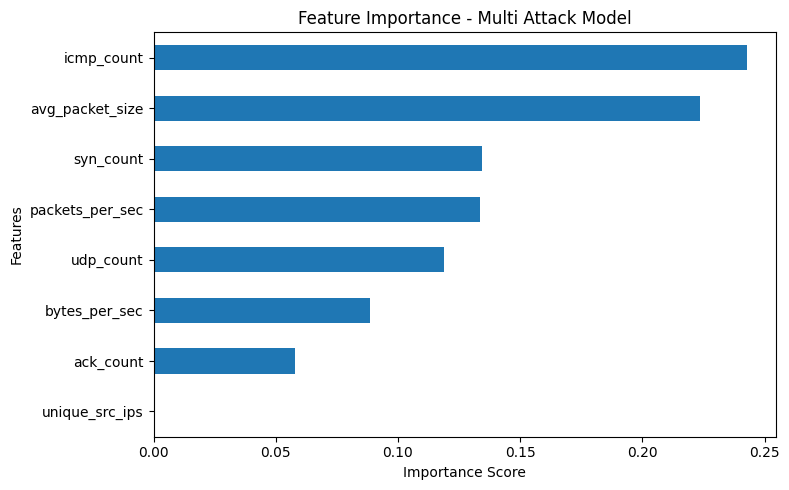

In [ ]:
#importance = pd.Series(model.feature_importances_, index=X.columns)
#importance.sort_values(ascending=False)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8,5))
importance.plot(kind='barh')
plt.title("Feature Importance - Multi Attack Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

##Save Model

In [ ]:
joblib.dump(model, "multi_attack_model.pkl")

['multi_attack_model.pkl']